# EDA - Gruppo 3: Giorni di consegna

**Domanda di business:** la promessa di consegna e' tarata bene?

- **Target (regressione):** giorni tra acquisto e consegna effettiva.
- **Baseline da battere:** la stima ufficiale dell'e-commerce (giorni tra acquisto e data stimata).
- **Vincolo:** solo feature note al momento del checkout (niente info sulla consegna effettiva tra le feature).

> Questo e' uno **scheletro**: le sezioni con `# TODO` sono la parte che scrivete voi durante la giornata (EDA, distribuzioni, errore della baseline).

## Setup
Aggiungiamo la radice del progetto al path per importare `src/`, poi carichiamo le funzioni condivise.

In [1]:
import sys
from pathlib import Path

# La radice del progetto e' la cartella che contiene 'src'.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import matplotlib.pyplot as plt

from src import data_loader
from src.sql import query, list_tables

pd.set_option('display.max_columns', 50)

## 1. Profilazione delle nove tabelle
Prima di costruire qualsiasi cosa: quante righe, che colonne, quanti nulli, quali chiavi. E' qui che, come dice la slide 6, nasce il 90% degli errori.

In [2]:
# Demo: carica tutte le tabelle grezze e mostra le dimensioni.
raw = data_loader.load_all_raw()
for name, df in raw.items():
    print(f'{name:22s} {df.shape[0]:>9,} righe x {df.shape[1]:>2} colonne')

orders                    99,441 righe x  8 colonne
order_items              112,650 righe x  7 colonne
order_payments           103,886 righe x  5 colonne
order_reviews             99,224 righe x  7 colonne
products                  32,951 righe x  9 colonne
customers                 99,441 righe x  5 colonne
sellers                    3,095 righe x  4 colonne
geolocation            1,000,163 righe x  5 colonne
category_translation          71 righe x  2 colonne


In [3]:
# Colonne (e tipo) di ogni tabella.
for name, df in raw.items():
    print(f'=== {name}  ({df.shape[0]:,} righe) ===')
    for col, dt in df.dtypes.items():
        print(f'  {col:32s} {dt}')
    print()

=== orders  (99,441 righe) ===
  order_id                         str
  customer_id                      str
  order_status                     str
  order_purchase_timestamp         datetime64[us]
  order_approved_at                datetime64[us]
  order_delivered_carrier_date     datetime64[us]
  order_delivered_customer_date    datetime64[us]
  order_estimated_delivery_date    datetime64[us]

=== order_items  (112,650 righe) ===
  order_id                         str
  order_item_id                    int64
  product_id                       str
  seller_id                        str
  shipping_limit_date              datetime64[us]
  price                            float64
  freight_value                    float64

=== order_payments  (103,886 righe) ===
  order_id                         str
  payment_sequential               int64
  payment_type                     str
  payment_installments             int64
  payment_value                    float64

=== order_reviews  (99,22

In [4]:
# Demo: anteprima di una tabella.
raw['orders'].head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [5]:
# TODO: per ogni tabella, profilare nulli, duplicati e chiavi.
#   - df.isna().mean()          -> % di nulli per colonna
#   - df[key].duplicated().sum() -> chiave davvero univoca?
#   - controllare i join 1:N (order_items, order_payments, order_reviews)


## 2. Esplorazione con SQL
Le stesse tabelle sono interrogabili in SQL (SQLite in memoria). Comodo per conteggi, group by e controlli rapidi.

In [6]:
# Tabelle disponibili nel database (le 9 grezze + order_table del Gruppo 3).
list_tables()

,name
0,category_translation
1,customers
2,geolocation
3,order_items
4,order_payments
5,order_reviews
6,order_table
7,orders
8,products
9,sellers


In [7]:
# Demo: distribuzione degli stati ordine.
query('''
    SELECT order_status, COUNT(*) AS n
    FROM orders
    GROUP BY order_status
    ORDER BY n DESC
''')

,order_status,n
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


In [8]:
# TODO: esplorazioni SQL vostre. Esempi da cui partire:
#   - ordini per stato/regione cliente
#   - quota di ordini multi-venditore (n_sellers > 1) in order_table
#   - volumi per periodo (mese di acquisto)


## 3. Costruzione della tabella ordine
`build_order_table()` porta tutto a grana-ordine (una riga = un ordine), filtra ai soli ordini consegnati e calcola **target** e **baseline**. Le relazioni 1:N sono gia' aggregate prima del join.

In [9]:
order_table = data_loader.build_order_table()
print(f'{order_table.shape[0]:,} ordini x {order_table.shape[1]} colonne')
order_table[['order_id', 'delivery_days', 'estimated_days',
             'n_items', 'n_sellers', 'total_price', 'customer_state']].head()

96,470 ordini x 23 colonne


,order_id,delivery_days,estimated_days,n_items,n_sellers,total_price,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,8.436574,15.544063,1,1,29.99,SP
1,53cdb2fc8bc7dce0b6741e2150273451,13.782037,19.137766,1,1,118.70,BA
2,47770eb9100c2d0c44946d9cf07ec65d,9.394213,26.639711,1,1,159.90,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,13.208750,26.188819,1,1,45.00,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,2.873877,12.112049,1,1,19.90,SP


## 4. Target e baseline
- `delivery_days` = giorni reali di consegna (quello che vogliamo prevedere).
- `estimated_days` = promessa dell'e-commerce (la baseline da battere).

**Questa e' la parte valutata: fatela voi.**

count    96470.000000
mean        12.558217
std          9.546156
min          0.533414
25%          6.766204
50%         10.217477
75%         15.720182
max        209.628611
Name: delivery_days, dtype: float64


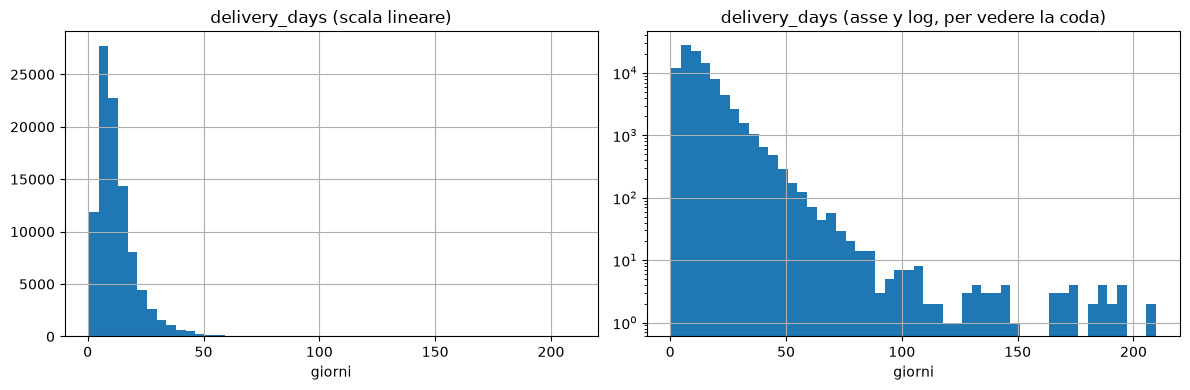

In [10]:
# Distribuzione del target: giorni di consegna effettivi.
print(order_table['delivery_days'].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
order_table['delivery_days'].hist(bins=50, ax=axes[0])
axes[0].set_title('delivery_days (scala lineare)')
axes[0].set_xlabel('giorni')

order_table['delivery_days'].hist(bins=50, ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_title('delivery_days (asse y log, per vedere la coda)')
axes[1].set_xlabel('giorni')

plt.tight_layout()
plt.show()

count    96470.000000
mean        11.178126
std         10.184354
min       -188.975081
25%          6.389815
50%         11.948102
75%         16.244065
max        146.016123
Name: baseline_error, dtype: float64

MAE baseline: 12.73 giorni
Quota di ordini in ritardo rispetto alla stima: 8.1%


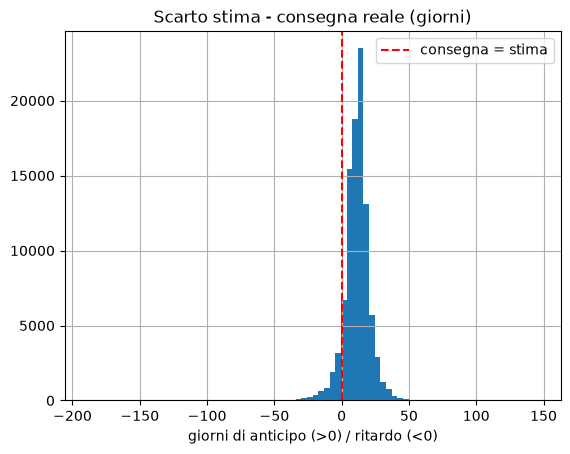


Col tasso di ritardo attuale (8.1%) non si puo' accorciare: bisognerebbe allungare la promessa di 3.8 giorni per scendere sotto il 5% di ritardi.


In [11]:
# Errore della baseline (stima ufficiale vs consegna reale).
# scarto > 0  -> consegnato in anticipo rispetto alla stima
# scarto < 0  -> consegnato in ritardo rispetto alla stima
order_table['baseline_error'] = order_table['estimated_days'] - order_table['delivery_days']

mae_baseline = (order_table['estimated_days'] - order_table['delivery_days']).abs().mean()
late_share = (order_table['baseline_error'] < 0).mean()

print(order_table['baseline_error'].describe())
print(f"\nMAE baseline: {mae_baseline:.2f} giorni")
print(f"Quota di ordini in ritardo rispetto alla stima: {late_share:.1%}")

order_table['baseline_error'].hist(bins=80)
plt.axvline(0, color='red', linestyle='--', label='consegna = stima')
plt.title('Scarto stima - consegna reale (giorni)')
plt.xlabel('giorni di anticipo (>0) / ritardo (<0)')
plt.legend()
plt.show()

# Quanto si potrebbe accorciare la promessa restando sotto il 5% di ritardi?
# Se accorciamo la stima di `x` giorni, un ordine finisce in ritardo quando
# baseline_error < x, quindi cerchiamo l'x per cui P(baseline_error < x) = 5%.
margin_5pct = order_table['baseline_error'].quantile(0.05)
if margin_5pct >= 0:
    print(f"\nSi puo' accorciare la promessa di {margin_5pct:.1f} giorni "
          f"restando sotto il 5% di ritardi.")
else:
    print(f"\nCol tasso di ritardo attuale ({late_share:.1%}) non si puo' accorciare: "
          f"bisognerebbe allungare la promessa di {-margin_5pct:.1f} giorni "
          f"per scendere sotto il 5% di ritardi.")

## 5. Prime distribuzioni e feature
Relazioni tra il target e i possibili driver: distanza, peso/volume, tempo di approvazione del pagamento, categoria, carico del venditore.

**Analisi completa svolta in [`02_analisi_feature_gruppo3.ipynb`](02_analisi_feature_gruppo3.ipynb)** (copertura, Spearman, controlli di qualita' e causalita', analisi a fasce). Qui solo il riepilogo.

**Sintesi** (dettagli e grafici in `02_analisi_feature_gruppo3.ipynb`):

- **Distanza venditore-cliente**: driver piu' forte (Spearman ~0.54). Media e max quasi identici; qualita' ok (coordinate anomale >4300 km sono 4 casi su ~96k).
- **Categoria prodotto**: forte spread tra categorie (consegna media ~10 -> ~21 gg).
- **Tempo di approvazione pagamento**: Spearman debole (~0.09) ma a fasce l'effetto e' netto (~12 gg se approvato <1h vs ~15 gg se >3 giorni, effetto boleto). Nota vicino al checkout -> usabile senza leakage.
- **Peso e volume**: effetto debole ma monotono a quintili (~+2 gg dal piu' leggero al piu' pesante). Segnale secondario.
- **Carico venditore** (finestra strettamente causale, 30gg): relazione non monotona, quasi piatta; pesa solo la coda dei venditori molto carichi (>30).

**Per il modello:** distanza e categoria portano il grosso del segnale; le altre tre sono deboli in forma lineare ma catturabili da un modello ad alberi grazie agli effetti a soglia osservati nell'analisi a fasce.

## 6. Salvataggio
Quando la tabella e' pronta, salvatela in `data/processed/` per riusarla nel training e nella dashboard senza ricostruirla.

In [13]:
# Scommentare quando la tabella e' pronta:
# data_loader.build_order_table(save=True)  # -> data/processed/order_table.parquet